In [1]:
# Cell 1 - Imports
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, BQ_DATASET_ANALYTICS, BQ_CLUSTERING_TRACTS

In [2]:
# Load features table from BQ - the geometry as a dataframe
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_ANALYTICS}.{BQ_CLUSTERING_TRACTS}"
client = bigquery.Client(project=GCS_PROJECT_ID)
# Exclude geometry
query = f"""
    SELECT *
    FROM `{table_id}`
"""
tract_df = client.query(query).to_arrow().to_pandas()
tract_df.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   tract_geoid                         83313 non-null  str    
 1   pop_ch_avg                          83313 non-null  float64
 2   pop_pctch_avg                       83313 non-null  float64
 3   estimated_census_housing_units      83313 non-null  int64  
 4   estimated_fcc_units                 83313 non-null  int64  
 5   median_bldr_dev_qtr_mi_cnt          83313 non-null  float64
 6   median_landuse_change_qtr_mi_cnt    83313 non-null  float64
 7   median_new_permit_qtr_mi_cnt        83313 non-null  float64
 8   median_pre_early_dev_qtr_mi_cnt     83313 non-null  float64
 9   median_dist_nearest_hotspot         83313 non-null  float64
 10  median_dist_nearest_fiber_m         83313 non-null  float64
 11  provider_competitive_landscape      83313 non-null  

In [3]:
# NA treatment — same as clustering notebook
tract_df['median_pre_early_dev_qtr_mi_cnt'] = tract_df['median_pre_early_dev_qtr_mi_cnt'].fillna(0)
tract_df['median_bldr_dev_qtr_mi_cnt'] = tract_df['median_bldr_dev_qtr_mi_cnt'].fillna(0)
tract_df['median_new_permit_qtr_mi_cnt'] = tract_df['median_new_permit_qtr_mi_cnt'].fillna(0)
tract_df['median_landuse_change_qtr_mi_cnt'] = tract_df['median_landuse_change_qtr_mi_cnt'].fillna(0)
tract_df['cable_penetration'] = tract_df['cable_penetration'].fillna(0)
tract_df['fiber_opportunity_gap'] = tract_df['fiber_opportunity_gap'].fillna(1.0)

fiber_dist_cap = tract_df['median_dist_nearest_fiber_m'].quantile(0.99)
tract_df['median_dist_nearest_fiber_m'] = tract_df['median_dist_nearest_fiber_m'].fillna(fiber_dist_cap)

hotspot_cap = tract_df['median_dist_nearest_hotspot'].max() * 1.25
tract_df['median_dist_nearest_hotspot'] = tract_df['median_dist_nearest_hotspot'].fillna(hotspot_cap)

# Drop columns not used as features
cols_to_drop = [col for col in tract_df.columns 
                if col in ['tract_geoid', 'estimated_fcc_units', 'provider_competitive_landscape', 'cable_future_gap', 'cluster']
                or col.endswith('_bin')]

y = tract_df['cluster']
X = tract_df.drop(columns=cols_to_drop)

feature_cols = X.columns.tolist()
print(f"Target classes: {sorted(y.unique())}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Features (13): ['pop_ch_avg', 'pop_pctch_avg', 'estimated_census_housing_units', 'median_bldr_dev_qtr_mi_cnt', 'median_landuse_change_qtr_mi_cnt', 'median_new_permit_qtr_mi_cnt', 'median_pre_early_dev_qtr_mi_cnt', 'median_dist_nearest_hotspot', 'median_dist_nearest_fiber_m', 'cable_penetration', 'fiber_opportunity_gap', 'fiber_speed_top_tier', 'provider_competitive_landscape_ord']
X shape: (83313, 13), y shape: (83313,)


In [4]:
# Model training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)
clf_lgb.fit(X_train, y_train)

y_pred = clf_lgb.predict(X_test)
print(classification_report(y_test, y_pred))

# Built-in gain importance
gain_importance = pd.Series(
    clf_lgb.booster_.feature_importance(importance_type='gain'),
    index=feature_cols
).sort_values(ascending=False)
print(gain_importance.round(1).to_string())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1926
[LightGBM] [Info] Number of data points in the train set: 66650, number of used features: 13
[LightGBM] [Info] Start training from score -2.738749
[LightGBM] [Info] Start training from score -3.623404
[LightGBM] [Info] Start training from score -1.084652
[LightGBM] [Info] Start training from score -4.492485
[LightGBM] [Info] Start training from score -1.065397
[LightGBM] [Info] Start training from score -1.537798
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

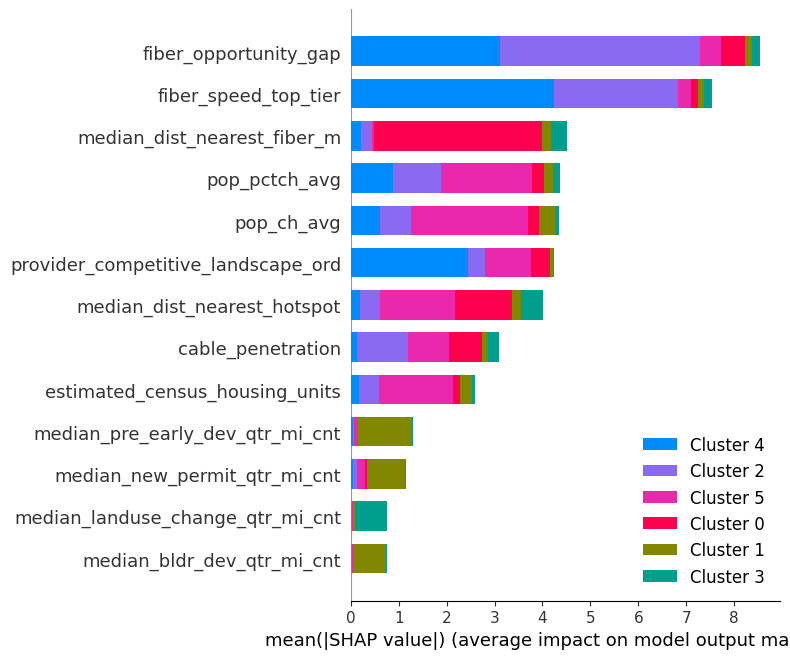

In [5]:
# Examine SHAP values
X_shap = X_test.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(clf_lgb)
shap_values = explainer.shap_values(X_shap)

# Global feature importance (mean |SHAP| across all classes)
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, plot_type="bar",
                  class_names=[f"Cluster {i}" for i in sorted(y.unique())])

In [6]:
# Global feature importance (mean |SHAP| across all classes), normalized to sum = 1
grand_mean = np.abs(shap_values).mean(axis=(0, 2))   # mean over samples & classes

importance_table = pd.DataFrame({
    'mean_abs_shap': grand_mean,
    'weight': grand_mean / grand_mean.sum(),
}, index=feature_cols).sort_values('weight', ascending=False)

print(f"Sum of weights: {importance_table['weight'].sum():.4f}")
print(importance_table.round(4).to_string())

Sum of weights: 1.0000
                                    mean_abs_shap  weight
fiber_opportunity_gap                      1.4223  0.1808
fiber_speed_top_tier                       1.2575  0.1598
median_dist_nearest_fiber_m                0.7529  0.0957
pop_pctch_avg                              0.7279  0.0925
pop_ch_avg                                 0.7252  0.0922
provider_competitive_landscape_ord         0.7069  0.0898
median_dist_nearest_hotspot                0.6694  0.0851
cable_penetration                          0.5139  0.0653
estimated_census_housing_units             0.4334  0.0551
median_pre_early_dev_qtr_mi_cnt            0.2166  0.0275
median_new_permit_qtr_mi_cnt               0.1920  0.0244
median_landuse_change_qtr_mi_cnt           0.1248  0.0159
median_bldr_dev_qtr_mi_cnt                 0.1248  0.0159


In [10]:
# NOTE: Temporary measure to save shap outputs because of jupyter render issues
import joblib
# NOTE: Multiple runs will need multiple versions of shap_values_k8 to be saved
k = 8
model = 'lightgbm'
v = 1
shap_name = f'data/shap_values_k{k}_{model}_v{v}.joblib'
X_shap_name = f'data/X_shap_k{k}_{model}_v{v}.joblib'
joblib.dump(shap_values, shap_name)
joblib.dump(X_shap, X_shap_name)
print(f"Saved shap_values shape: {shap_values.shape}, X_shap shape: {X_shap.shape}")

Saved shap_values shape: (2000, 13, 6), X_shap shape: (2000, 13)


In [11]:
# ── Validate domain (bucket) weights: Growth / Telecom / Demo ──────────────────
# Per-feature weight = mean |SHAP| over samples & classes, normalized to sum=1
shap_weights = pd.Series(
    np.abs(shap_values).mean(axis=(0, 2)),
    index=feature_cols,
)
shap_weights = shap_weights / shap_weights.sum()

growth_features = [
    "median_landuse_change_qtr_mi_cnt",
    "median_pre_early_dev_qtr_mi_cnt",
    "median_bldr_dev_qtr_mi_cnt",
    "median_new_permit_qtr_mi_cnt",
    "median_dist_nearest_hotspot",
]
telecom_features = [
    "cable_penetration",
    "fiber_opportunity_gap",
    "fiber_speed_top_tier",
    "median_dist_nearest_fiber_m",
    "provider_competitive_landscape_ord",
]
demo_features = [
    "pop_ch_avg",
    "pop_pctch_avg",
    "estimated_census_housing_units",
]
groups = {"growth": growth_features, "telecom": telecom_features, "demo": demo_features}

# Sanity: every model feature maps to exactly one bucket (catches renames / extras)
assigned = growth_features + telecom_features + demo_features
missing = set(feature_cols) - set(assigned)
extra = set(assigned) - set(feature_cols)
assert not missing, f"Model features not assigned to a bucket: {missing}"
assert not extra, f"Bucketed features not in model: {extra}"

group_shap = {g: shap_weights[cols].sum() for g, cols in groups.items()}
total = sum(group_shap.values())
group_weights = {g: v / total for g, v in group_shap.items()}

print("=" * 60)
print("DOMAIN (BUCKET) WEIGHTS  —  share of total raw |SHAP|")
print("=" * 60)
for g, w in group_weights.items():
    print(f"  {g:<8}: {w:.3f}   (raw |SHAP| sum = {group_shap[g]:.4f})")
print(f"  {'TOTAL':<8}: {sum(group_weights.values()):.3f}")

expected = {"growth": 0.40, "telecom": 0.44, "demo": 0.16}
print("\nDelta vs locked v1 (0.40 / 0.44 / 0.16):")
for g in groups:
    print(f"  {g:<8}: actual {group_weights[g]:.3f}  vs expected {expected[g]:.2f}"
          f"  (Δ {group_weights[g] - expected[g]:+.3f})")

DOMAIN (BUCKET) WEIGHTS  —  share of total raw |SHAP|
  growth  : 0.169   (raw |SHAP| sum = 0.1687)
  telecom : 0.591   (raw |SHAP| sum = 0.5915)
  demo    : 0.240   (raw |SHAP| sum = 0.2398)
  TOTAL   : 1.000

Delta vs locked v1 (0.40 / 0.44 / 0.16):
  growth  : actual 0.169  vs expected 0.40  (Δ -0.231)
  telecom : actual 0.591  vs expected 0.44  (Δ +0.151)
  demo    : actual 0.240  vs expected 0.16  (Δ +0.080)
